In [1]:
# Imports & Load All Artifacts

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import joblib
import json
import os
import warnings

from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)
import mlflow
from mlflow.tracking import MlflowClient

warnings.filterwarnings("ignore")
shap.initjs()

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 110,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# ── NGN currency formatter ───────────────────────────────────
def ngn(x):
    if x >= 1_000_000_000:
        return f"₦{x/1_000_000_000:.1f}B"
    elif x >= 1_000_000:
        return f"₦{x/1_000_000:.1f}M"
    elif x >= 1_000:
        return f"₦{x/1_000:.0f}K"
    return f"₦{x:.0f}"

# ── Load artifacts ───────────────────────────────────────────
DATA_DIR  = "../data/processed"
MODEL_DIR = "../models"

print("⏳ Loading artifacts...")

X_test  = pd.read_parquet(f"{DATA_DIR}/X_test.parquet")
y_test  = pd.read_parquet(f"{DATA_DIR}/y_test.parquet").squeeze()
X_val   = pd.read_parquet(f"{DATA_DIR}/X_val.parquet")
y_val   = pd.read_parquet(f"{DATA_DIR}/y_val.parquet").squeeze()

with open(f"{MODEL_DIR}/model_config.json") as f:
    model_config = json.load(f)

best_model = joblib.load(model_config["model_path"])
FEATURES   = model_config["features"]
THRESHOLD  = model_config["threshold"]

# Align features
X_test = X_test[FEATURES]
X_val  = X_val[FEATURES]

# Generate predictions
test_prob  = best_model.predict_proba(X_test)[:, 1]
test_pred  = (test_prob >= THRESHOLD).astype(int)
val_prob   = best_model.predict_proba(X_val)[:, 1]

print(f"Artifacts loaded")
print(f"\n  Model       : {model_config['model_name']}")
print(f"  Model Type  : {model_config['model_type']}")
print(f"  Threshold   : {THRESHOLD}")
print(f"  Features    : {len(FEATURES)}")
print(f"  Test rows   : {len(X_test):,}")
print(f"  Test fraud  : {y_test.sum():,} ({y_test.mean()*100:.2f}%)")

/home/thedataboy/dev/fraud-detection-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Loading artifacts...
Artifacts loaded

  Model       : XGBoost Baseline
  Model Type  : XGBClassifier
  Threshold   : 0.53
  Features    : 58
  Test rows   : 625,000
  Test fraud  : 22,519 (3.60%)


CONFUSION MATRIX DEEP DIVE

                    PREDICTED
                  Legit      Fraud
  ACTUAL  Legit    141,247    461,234   ← 76.6% of legit flagged
          Fraud      1,365     21,154   ← 93.9% of fraud caught

  TRUE  NEGATIVES (TN) :  141,247  Legit correctly approved    ✅
  FALSE POSITIVES (FP) :  461,234  Legit wrongly blocked       ❌
  FALSE NEGATIVES (FN) :    1,365  Fraud wrongly approved      ❌
  TRUE  POSITIVES (TP) :   21,154  Fraud correctly blocked     ✅



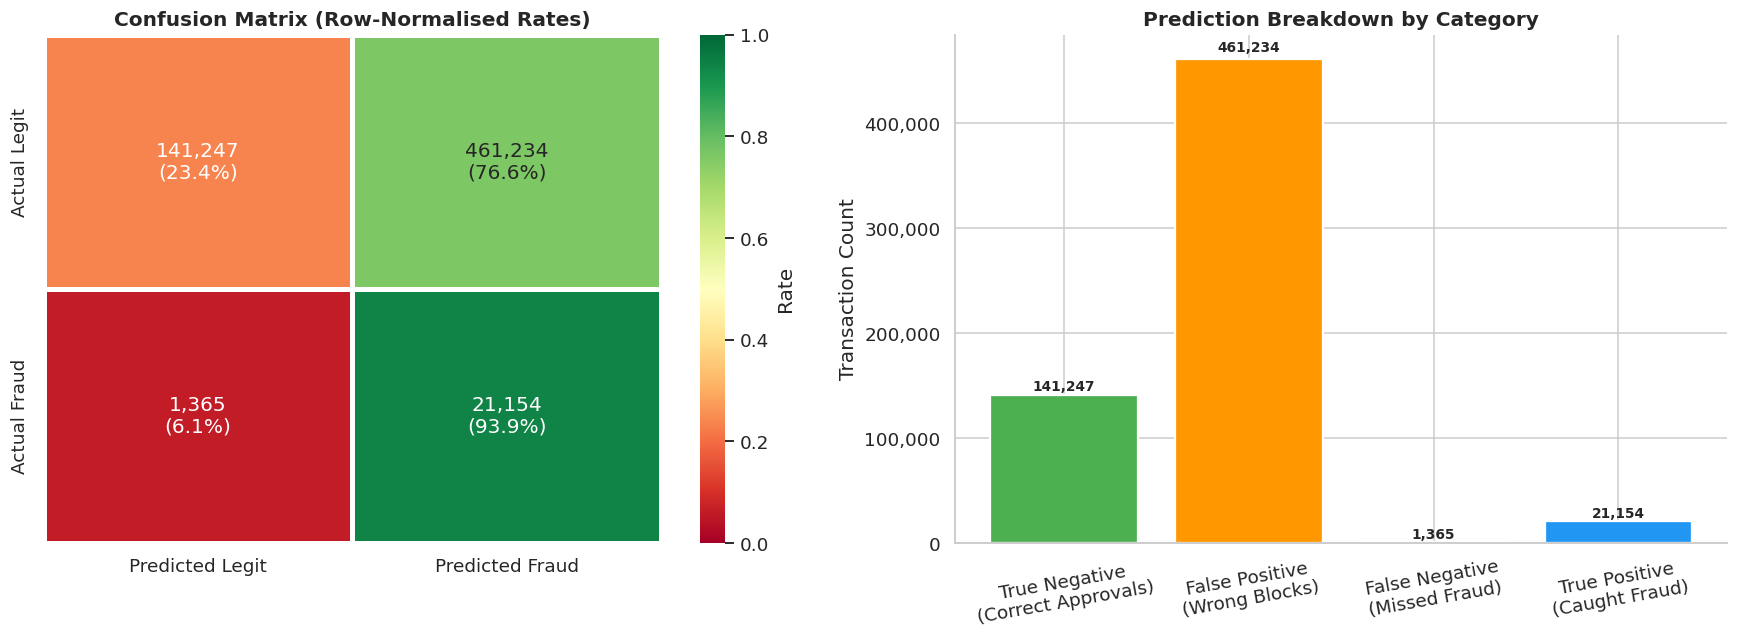

In [2]:
# Confusion Matrix Deep Dive

# The confusion matrix tells us the COST of our errors.
# In fraud detection:
#   False Negative (FN) = missed fraud   → financial loss
#   False Positive (FP) = wrong flag     → customer friction

cm = confusion_matrix(y_test, test_pred)
tn, fp, fn, tp = cm.ravel()

print("=" * 65)
print("CONFUSION MATRIX DEEP DIVE")
print("=" * 65)

print(f"""
                    PREDICTED
                  Legit      Fraud
  ACTUAL  Legit   {tn:>8,}   {fp:>8,}   ← {fp/(tn+fp)*100:.1f}% of legit flagged
          Fraud   {fn:>8,}   {tp:>8,}   ← {tp/(tp+fn)*100:.1f}% of fraud caught

  TRUE  NEGATIVES (TN) : {tn:>8,}  Legit correctly approved    ✅
  FALSE POSITIVES (FP) : {fp:>8,}  Legit wrongly blocked       ❌
  FALSE NEGATIVES (FN) : {fn:>8,}  Fraud wrongly approved      ❌
  TRUE  POSITIVES (TP) : {tp:>8,}  Fraud correctly blocked     ✅
""")

# ── Visual confusion matrix ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
cm_pct = cm.astype(float)
cm_pct[0] = cm_pct[0] / cm_pct[0].sum() * 100
cm_pct[1] = cm_pct[1] / cm_pct[1].sum() * 100

labels = [
    [f"{tn:,}\n({tn/(tn+fp)*100:.1f}%)", f"{fp:,}\n({fp/(tn+fp)*100:.1f}%)"],
    [f"{fn:,}\n({fn/(fn+tp)*100:.1f}%)", f"{tp:,}\n({tp/(fn+tp)*100:.1f}%)"]
]

sns.heatmap(
    [[tn/(tn+fp), fp/(tn+fp)],
     [fn/(fn+tp), tp/(fn+tp)]],
    annot=np.array(labels),
    fmt="",
    cmap="RdYlGn",
    ax=axes[0],
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
    vmin=0, vmax=1,
    linewidths=2,
    cbar_kws={"label": "Rate"}
)
axes[0].set_title("Confusion Matrix (Row-Normalised Rates)")

# Error type breakdown
error_data = pd.DataFrame({
    "Category": [
        "True Negative\n(Correct Approvals)",
        "False Positive\n(Wrong Blocks)",
        "False Negative\n(Missed Fraud)",
        "True Positive\n(Caught Fraud)"
    ],
    "Count": [tn, fp, fn, tp],
    "Color": ["#4CAF50", "#FF9800", "#F44336", "#2196F3"]
})

bars = axes[1].bar(
    error_data["Category"],
    error_data["Count"],
    color=error_data["Color"],
    edgecolor="white", linewidth=1.5
)
axes[1].set_title("Prediction Breakdown by Category")
axes[1].set_ylabel("Transaction Count")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x:,.0f}"
    )
)
for bar, val in zip(bars, error_data["Count"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.01,
        f"{val:,}",
        ha="center", va="bottom", fontsize=9, fontweight="bold"
    )
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("reports/confusion_matrix_deep_dive.png", bbox_inches="tight")
plt.show()

BUSINESS COST ANALYSIS

  COST ASSUMPTIONS:
  Average transaction amount : ₦748K
  Fraud recovery rate        : 20%
  Cost per False Negative    : ₦599K
    (fraud loss per missed transaction)
  Cost per False Positive    : ₦500
    (ops cost per wrong block)

  COST COMPARISON:

  NO MODEL (approve all):
    Missed fraud   :   22,519 transactions
    Total cost     :          ₦13.5B

  OUR MODEL (threshold=0.53):
    False Negatives:    1,365 transactions →         ₦817.1M
    False Positives:  461,234 transactions →         ₦230.6M
    Total cost     :           ₦1.0B

  SAVINGS vs NO MODEL:
    Cost saved     :          ₦12.4B
    Saving %       : 92.2%

  PERFECT MODEL:
    Total cost     :              ₦0
    Remaining gap  :           ₦1.0B

⏳ Computing cost across all thresholds...

  OPTIMAL THRESHOLD (by business cost): 0.37
  Minimum total cost                  : ₦245.4M
  Current threshold cost              : ₦1.0B
  Difference                          : ₦802.3M


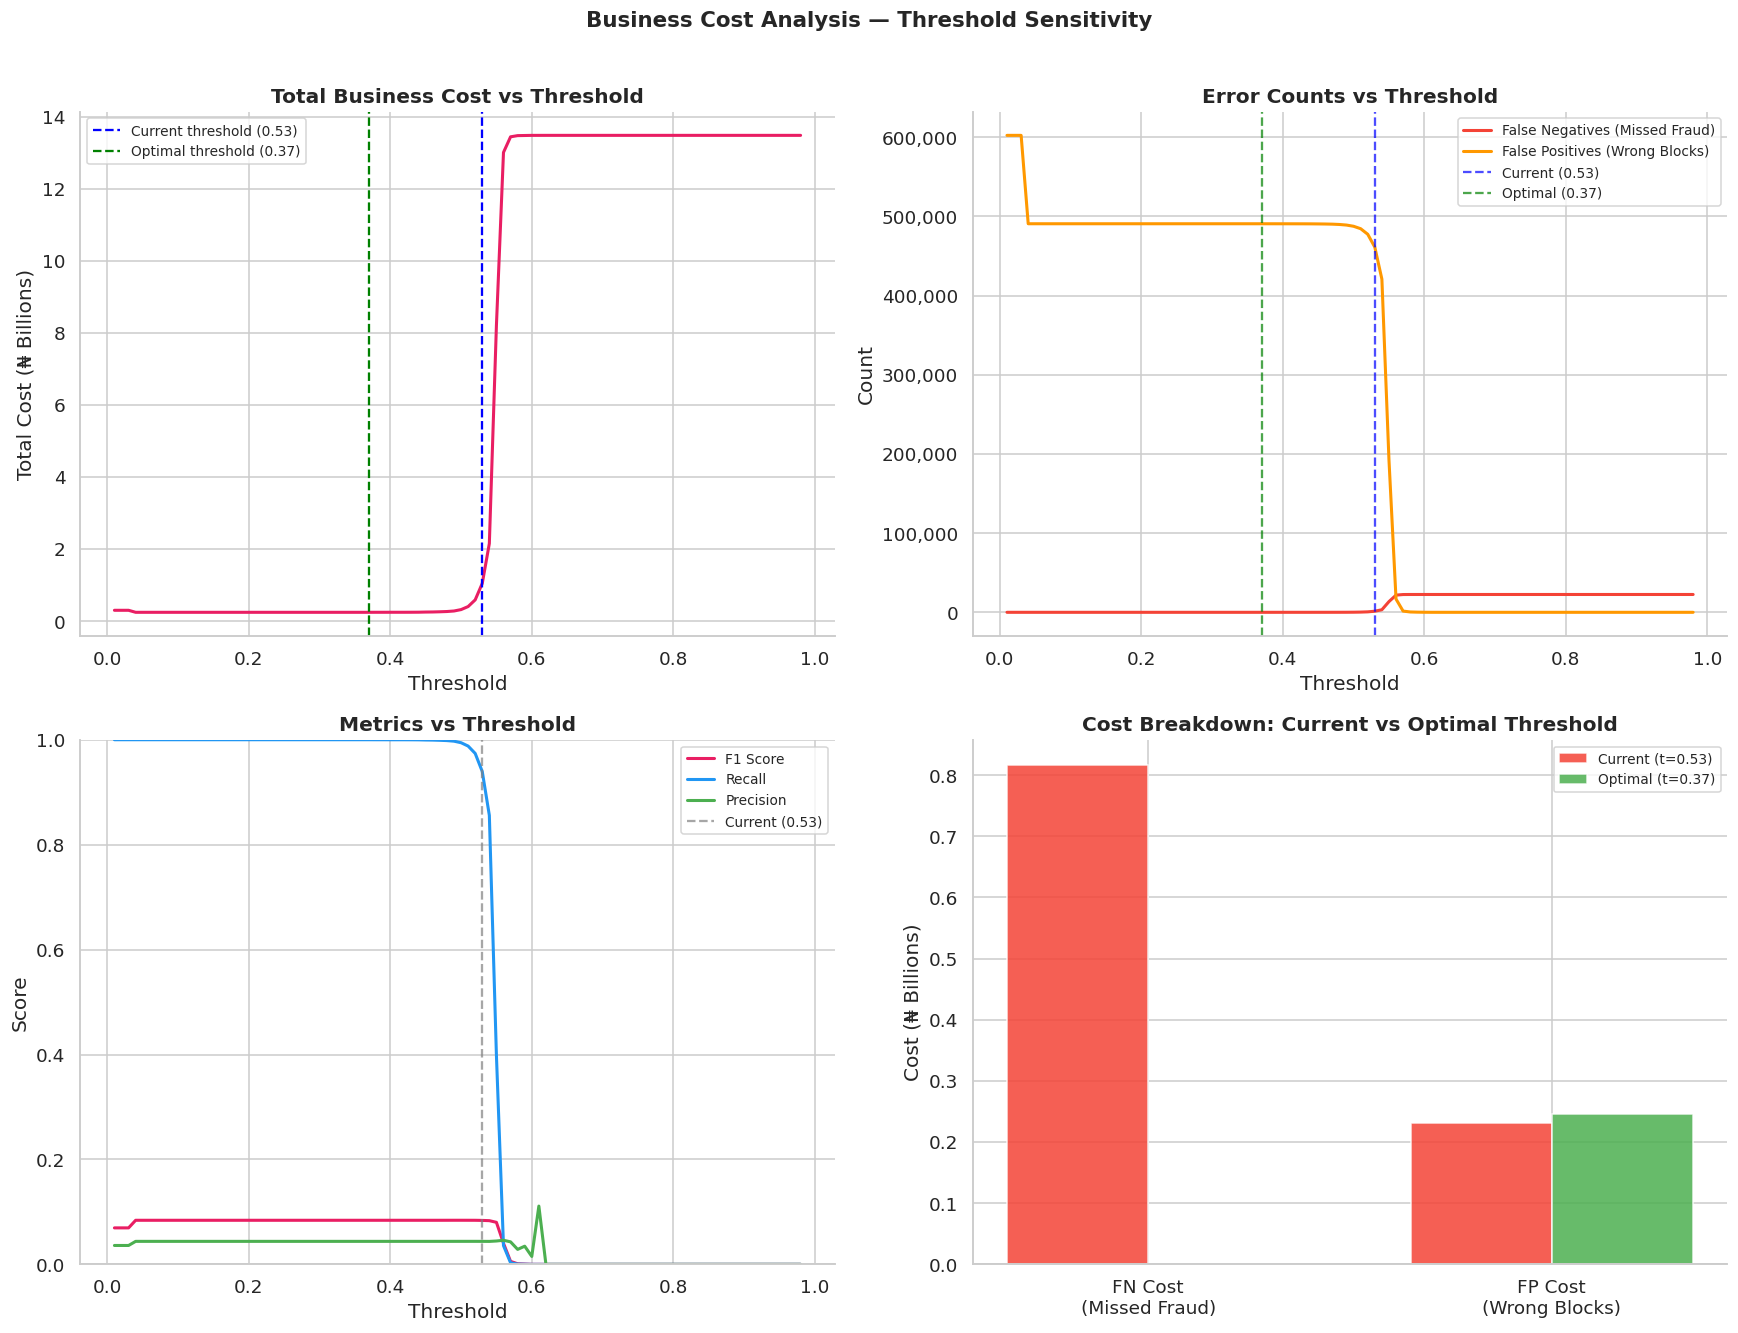

In [3]:
# Business Cost Analysis in Nigerian Naira

# Translates model errors into real financial impact.
#
# COST ASSUMPTIONS (Nigerian fintech context):
#   Average transaction: ₦748,267 (from EDA)
#   Fraud recovery rate: ~20% (typical for Nigerian banks)
#   False positive cost: ₦500 per transaction
#     (customer service call + goodwill credit)
#   Fraud loss per transaction: ₦748,267 × 80% = ₦598,614
#     (amount lost minus recovery)

# ── Cost parameters ──────────────────────────────────────────
AVG_TXN_AMOUNT   = 748_267      # From EDA
FRAUD_RECOVERY   = 0.20         # 20% recovered through chargebacks
FRAUD_LOSS_RATE  = 1 - FRAUD_RECOVERY

COST_PER_FP      = 500          # ₦500 per false positive (ops cost)
COST_PER_FN      = AVG_TXN_AMOUNT * FRAUD_LOSS_RATE  # ₦598,614

print("=" * 65)
print("BUSINESS COST ANALYSIS")
print("=" * 65)

print(f"\n  COST ASSUMPTIONS:")
print(f"  Average transaction amount : {ngn(AVG_TXN_AMOUNT)}")
print(f"  Fraud recovery rate        : {FRAUD_RECOVERY*100:.0f}%")
print(f"  Cost per False Negative    : {ngn(COST_PER_FN)}")
print(f"    (fraud loss per missed transaction)")
print(f"  Cost per False Positive    : {ngn(COST_PER_FP)}")
print(f"    (ops cost per wrong block)")

# ── Current model costs ──────────────────────────────────────
cost_fn    = fn * COST_PER_FN
cost_fp    = fp * COST_PER_FP
total_cost = cost_fn + cost_fp

# ── No-model baseline (approve everything) ───────────────────
baseline_fn_count  = y_test.sum()
baseline_cost      = baseline_fn_count * COST_PER_FN

# ── Perfect model cost ───────────────────────────────────────
perfect_cost = 0

print(f"\n{'='*65}")
print(f"  COST COMPARISON:")
print(f"{'='*65}")
print(f"""
  NO MODEL (approve all):
    Missed fraud   : {baseline_fn_count:>8,} transactions
    Total cost     : {ngn(baseline_cost):>15}

  OUR MODEL (threshold={THRESHOLD}):
    False Negatives: {fn:>8,} transactions → {ngn(cost_fn):>15}
    False Positives: {fp:>8,} transactions → {ngn(cost_fp):>15}
    Total cost     : {ngn(total_cost):>15}

  SAVINGS vs NO MODEL:
    Cost saved     : {ngn(baseline_cost - total_cost):>15}
    Saving %       : {(baseline_cost - total_cost)/baseline_cost*100:.1f}%

  PERFECT MODEL:
    Total cost     : {ngn(0):>15}
    Remaining gap  : {ngn(total_cost):>15}
""")

# ── Threshold sensitivity: cost vs threshold ─────────────────
print("⏳ Computing cost across all thresholds...")
thresholds  = np.arange(0.01, 0.99, 0.01)
costs       = []
fn_counts   = []
fp_counts   = []
f1_scores   = []
recalls     = []
precisions  = []

for t in thresholds:
    y_pred_t = (test_prob >= t).astype(int)
    cm_t     = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()

    cost_t = (fn_t * COST_PER_FN) + (fp_t * COST_PER_FP)
    costs.append(cost_t)
    fn_counts.append(fn_t)
    fp_counts.append(fp_t)
    f1_scores.append(f1_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))

optimal_idx       = np.argmin(costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = costs[optimal_idx]

print(f"\n  OPTIMAL THRESHOLD (by business cost): {optimal_threshold:.2f}")
print(f"  Minimum total cost                  : {ngn(optimal_cost)}")
print(f"  Current threshold cost              : {ngn(total_cost)}")
print(f"  Difference                          : {ngn(total_cost - optimal_cost)}")

# ── Plot threshold sensitivity ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Total cost vs threshold
axes[0, 0].plot(thresholds, [c/1e9 for c in costs],
                color="#E91E63", linewidth=2)
axes[0, 0].axvline(THRESHOLD, color="blue", linestyle="--",
                   label=f"Current threshold ({THRESHOLD})")
axes[0, 0].axvline(optimal_threshold, color="green", linestyle="--",
                   label=f"Optimal threshold ({optimal_threshold:.2f})")
axes[0, 0].set_title("Total Business Cost vs Threshold")
axes[0, 0].set_xlabel("Threshold")
axes[0, 0].set_ylabel("Total Cost (₦ Billions)")
axes[0, 0].legend(fontsize=9)

# FP and FN counts vs threshold
axes[0, 1].plot(thresholds, fn_counts, color="#F44336",
                linewidth=2, label="False Negatives (Missed Fraud)")
axes[0, 1].plot(thresholds, fp_counts, color="#FF9800",
                linewidth=2, label="False Positives (Wrong Blocks)")
axes[0, 1].axvline(THRESHOLD, color="blue", linestyle="--",
                   alpha=0.7, label=f"Current ({THRESHOLD})")
axes[0, 1].axvline(optimal_threshold, color="green", linestyle="--",
                   alpha=0.7, label=f"Optimal ({optimal_threshold:.2f})")
axes[0, 1].set_title("Error Counts vs Threshold")
axes[0, 1].set_xlabel("Threshold")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(fontsize=9)
axes[0, 1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:,.0f}")
)

# F1, Precision, Recall vs threshold
axes[1, 0].plot(thresholds, f1_scores, color="#E91E63",
                linewidth=2, label="F1 Score")
axes[1, 0].plot(thresholds, recalls, color="#2196F3",
                linewidth=2, label="Recall")
axes[1, 0].plot(thresholds, precisions, color="#4CAF50",
                linewidth=2, label="Precision")
axes[1, 0].axvline(THRESHOLD, color="gray", linestyle="--",
                   alpha=0.7, label=f"Current ({THRESHOLD})")
axes[1, 0].set_title("Metrics vs Threshold")
axes[1, 0].set_xlabel("Threshold")
axes[1, 0].set_ylabel("Score")
axes[1, 0].legend(fontsize=9)
axes[1, 0].set_ylim(0, 1)

# Cost breakdown at optimal threshold
opt_pred = (test_prob >= optimal_threshold).astype(int)
opt_cm   = confusion_matrix(y_test, opt_pred)
opt_tn, opt_fp, opt_fn, opt_tp = opt_cm.ravel()
opt_cost_fn = opt_fn * COST_PER_FN
opt_cost_fp = opt_fp * COST_PER_FP

categories = ["FN Cost\n(Missed Fraud)", "FP Cost\n(Wrong Blocks)"]
current_vals = [cost_fn/1e9, cost_fp/1e9]
optimal_vals = [opt_cost_fn/1e9, opt_cost_fp/1e9]

x = np.arange(len(categories))
w = 0.35
axes[1, 1].bar(x - w/2, current_vals, w, label=f"Current (t={THRESHOLD})",
               color="#F44336", alpha=0.85)
axes[1, 1].bar(x + w/2, optimal_vals, w,
               label=f"Optimal (t={optimal_threshold:.2f})",
               color="#4CAF50", alpha=0.85)
axes[1, 1].set_title("Cost Breakdown: Current vs Optimal Threshold")
axes[1, 1].set_ylabel("Cost (₦ Billions)")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(categories)
axes[1, 1].legend(fontsize=9)

plt.suptitle("Business Cost Analysis — Threshold Sensitivity",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("reports/business_cost_analysis.png", bbox_inches="tight")
plt.show()

SHAP VALUE ANALYSIS
  Computing SHAP on 2000 sample:
  Fraud     : 500
  Legitimate: 1500
  ⏳ This takes ~1–2 minutes...
  SHAP values computed
  Shape: (2000, 58)

  Plotting SHAP summary...


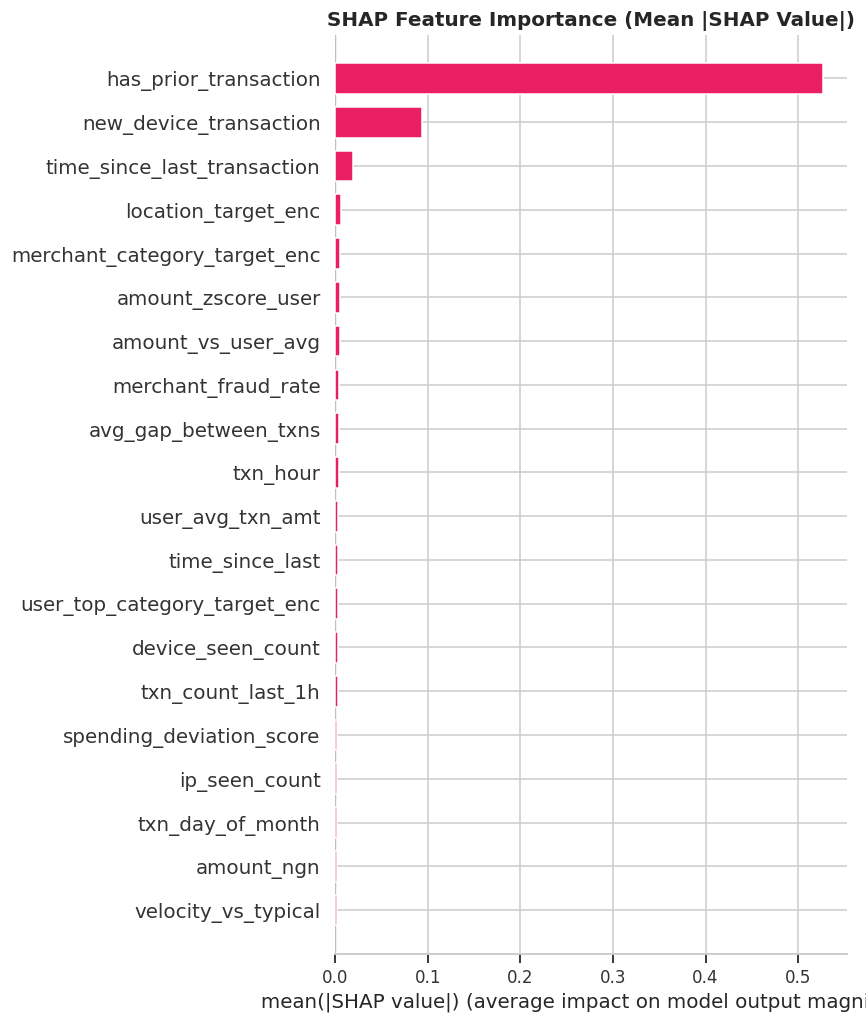

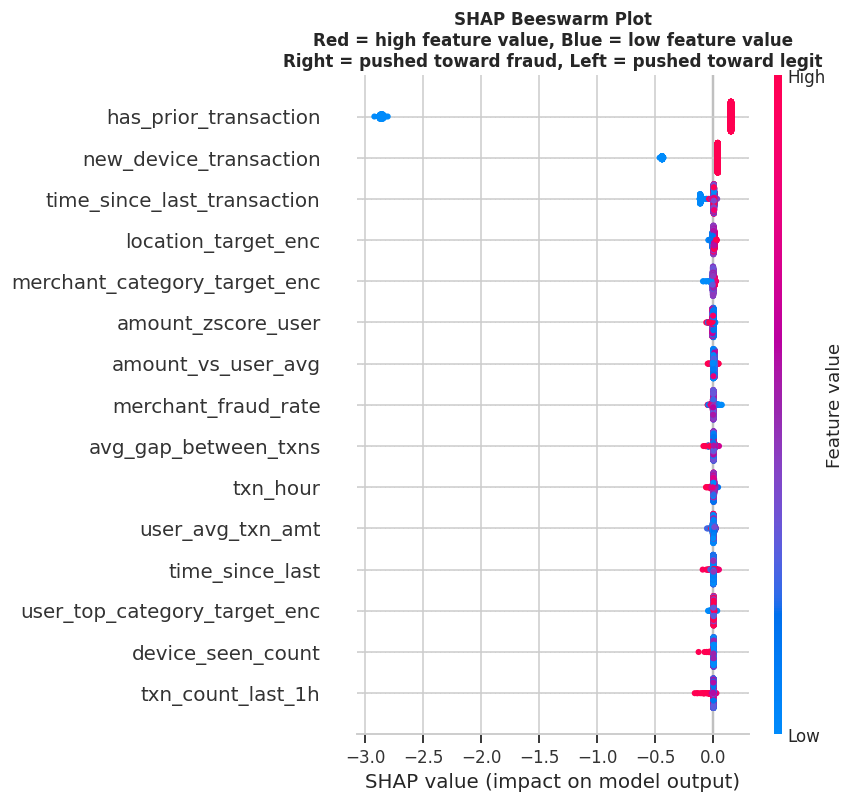

In [4]:
# SHAP Value Analysis

# SHAP = SHapley Additive exPlanations
#
# Answers: "WHY did the model give this transaction
#           a fraud score of 0.73?"
#
# For each prediction:
#   SHAP value > 0 → pushed score TOWARD fraud
#   SHAP value < 0 → pushed score AWAY from fraud
#
# Critical for:
#   1. Regulatory compliance (explain decisions)
#   2. Debugging model behaviour
#   3. Feature selection validation
#   4. Customer dispute resolution

print("=" * 65)
print("SHAP VALUE ANALYSIS")
print("=" * 65)

# ── Compute SHAP values ──────────────────────────────────────
# Use a sample for speed (SHAP on 625k rows is slow)
SHAP_SAMPLE = 2000
np.random.seed(42)

# Stratified sample (keep fraud proportion)
fraud_idx  = np.where(y_test == 1)[0]
legit_idx  = np.where(y_test == 0)[0]

n_fraud_sample = min(500, len(fraud_idx))
n_legit_sample = SHAP_SAMPLE - n_fraud_sample

sample_idx = np.concatenate([
    np.random.choice(fraud_idx, n_fraud_sample, replace=False),
    np.random.choice(legit_idx, n_legit_sample, replace=False)
])
np.random.shuffle(sample_idx)

X_shap = X_test.iloc[sample_idx]
y_shap = y_test.iloc[sample_idx]

print(f"  Computing SHAP on {SHAP_SAMPLE} sample:")
print(f"  Fraud     : {n_fraud_sample}")
print(f"  Legitimate: {n_legit_sample}")
print(f"  ⏳ This takes ~1–2 minutes...")

explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

print(f"  SHAP values computed")
print(f"  Shape: {shap_values.shape}")

# ── Plot 1: Summary plot (global feature importance) ─────────
print("\n  Plotting SHAP summary...")
plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    plot_type="bar",
    max_display=20,
    show=False,
    color="#E91E63"
)
plt.title("SHAP Feature Importance (Mean |SHAP Value|)",
          fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("reports/shap_summary_importance.png", bbox_inches="tight")
plt.show()

# ── Plot 2: Beeswarm plot (direction + magnitude) ─────────────
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=FEATURES,
    max_display=15,
    show=False,
)
plt.title(
    "SHAP Beeswarm Plot\n"
    "Red = high feature value, Blue = low feature value\n"
    "Right = pushed toward fraud, Left = pushed toward legit",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
plt.savefig("reports/shap_summary_beeswarm.png", bbox_inches="tight")
plt.show()

In [5]:
# Individual Transaction Explanations

# Explain specific predictions — answers "why was THIS
# transaction flagged?"
# Critical for customer dispute resolution and compliance.

print("=" * 65)
print("INDIVIDUAL TRANSACTION EXPLANATIONS")
print("=" * 65)

# ── Find interesting transactions ────────────────────────────
test_prob_series = pd.Series(test_prob, index=X_test.index)
test_pred_series = pd.Series(test_pred, index=X_test.index)

# True Positive: High-confidence fraud correctly caught
tp_mask    = (y_test == 1) & (test_pred_series == 1)
tp_indices = X_test[tp_mask].index
high_conf_tp = test_prob_series[tp_mask].nlargest(1).index[0]

# False Negative: Fraud we MISSED (most dangerous error)
fn_mask    = (y_test == 1) & (test_pred_series == 0)
fn_indices = X_test[fn_mask].index
if len(fn_indices) > 0:
    worst_fn = test_prob_series[fn_mask].nsmallest(1).index[0]

# False Positive: Legitimate transaction wrongly blocked
fp_mask    = (y_test == 0) & (test_pred_series == 1)
fp_indices = X_test[fp_mask].index
if len(fp_indices) > 0:
    high_conf_fp = test_prob_series[fp_mask].nlargest(1).index[0]

def explain_transaction(idx, label, actual, predicted_prob):
    """Generate SHAP waterfall explanation for one transaction."""

    # Get position in shap sample
    if idx in X_shap.index:
        shap_idx = list(X_shap.index).index(idx)
        sv = shap_values[shap_idx]
    else:
        # Compute SHAP for this specific transaction
        single = X_test.loc[[idx]]
        sv = explainer.shap_values(single)[0]

    # Top contributing features
    feature_shap = pd.DataFrame({
        "Feature": FEATURES,
        "SHAP Value": sv,
        "Feature Value": X_test.loc[idx].values
    }).sort_values("SHAP Value", key=abs, ascending=False).head(10)

    print(f"\n{'─'*65}")
    print(f"  {label}")
    print(f"  Fraud Probability : {predicted_prob:.4f}")
    print(f"  Decision          : {'FRAUD' if predicted_prob >= THRESHOLD else 'LEGIT'}")
    print(f"  Actual Label      : {'FRAUD' if actual == 1 else 'LEGIT'}")
    print(f"  Correct           : {'✅' if (predicted_prob >= THRESHOLD) == actual else '❌'}")
    print(f"\n  TOP FEATURES DRIVING THIS DECISION:")
    print(f"  {'Feature':<35} {'Value':>10} {'SHAP':>10} {'Direction'}")
    print(f"  {'─'*65}")
    for _, row in feature_shap.iterrows():
        direction = "→ FRAUD" if row["SHAP Value"] > 0 else "→ LEGIT"
        print(
            f"  {row['Feature']:<35} "
            f"{row['Feature Value']:>10.3f} "
            f"{row['SHAP Value']:>10.4f}  {direction}"
        )

# ── Explain key transactions ─────────────────────────────────
explain_transaction(
    high_conf_tp,
    "CASE 1: TRUE POSITIVE (Fraud Correctly Caught)",
    actual=1,
    predicted_prob=test_prob_series[high_conf_tp]
)

if len(fn_indices) > 0:
    explain_transaction(
        worst_fn,
        "CASE 2: FALSE NEGATIVE (Fraud We MISSED — Most Dangerous)",
        actual=1,
        predicted_prob=test_prob_series[worst_fn]
    )

if len(fp_indices) > 0:
    explain_transaction(
        high_conf_fp,
        "CASE 3: FALSE POSITIVE (Legitimate Transaction Wrongly Blocked)",
        actual=0,
        predicted_prob=test_prob_series[high_conf_fp]
    )

INDIVIDUAL TRANSACTION EXPLANATIONS

─────────────────────────────────────────────────────────────────
  CASE 1: TRUE POSITIVE (Fraud Correctly Caught)
  Fraud Probability : 0.6154
  Decision          : FRAUD
  Actual Label      : FRAUD
  Correct           : ✅

  TOP FEATURES DRIVING THIS DECISION:
  Feature                                  Value       SHAP Direction
  ─────────────────────────────────────────────────────────────────
  ip_seen_count                          352.000     0.1805  → FRAUD
  has_prior_transaction                    1.000     0.1564  → FRAUD
  new_device_transaction                   1.000     0.0393  → FRAUD
  merchant_category_target_enc             0.036     0.0126  → FRAUD
  txn_day_of_month                        26.000     0.0118  → FRAUD
  txn_month                               11.000     0.0116  → FRAUD
  user_avg_txn_amt                    1424365.453     0.0105  → FRAUD
  time_since_last_transaction           3949.125     0.0085  → FRAUD
  txn_cou

ERROR ANALYSIS — PATTERNS IN MISTAKES

  Error type distribution:
    False Positive      :  461,234  (73.80%)
    True Negative       :  141,247  (22.60%)
    True Positive       :   21,154  (3.38%)
    False Negative      :    1,365  (0.22%)

FALSE NEGATIVE ANALYSIS (Fraud We Missed)
  Total missed fraud: 1,365
  Avg fraud prob assigned to missed fraud: 0.5170
  Max fraud prob for missed fraud: 0.5300


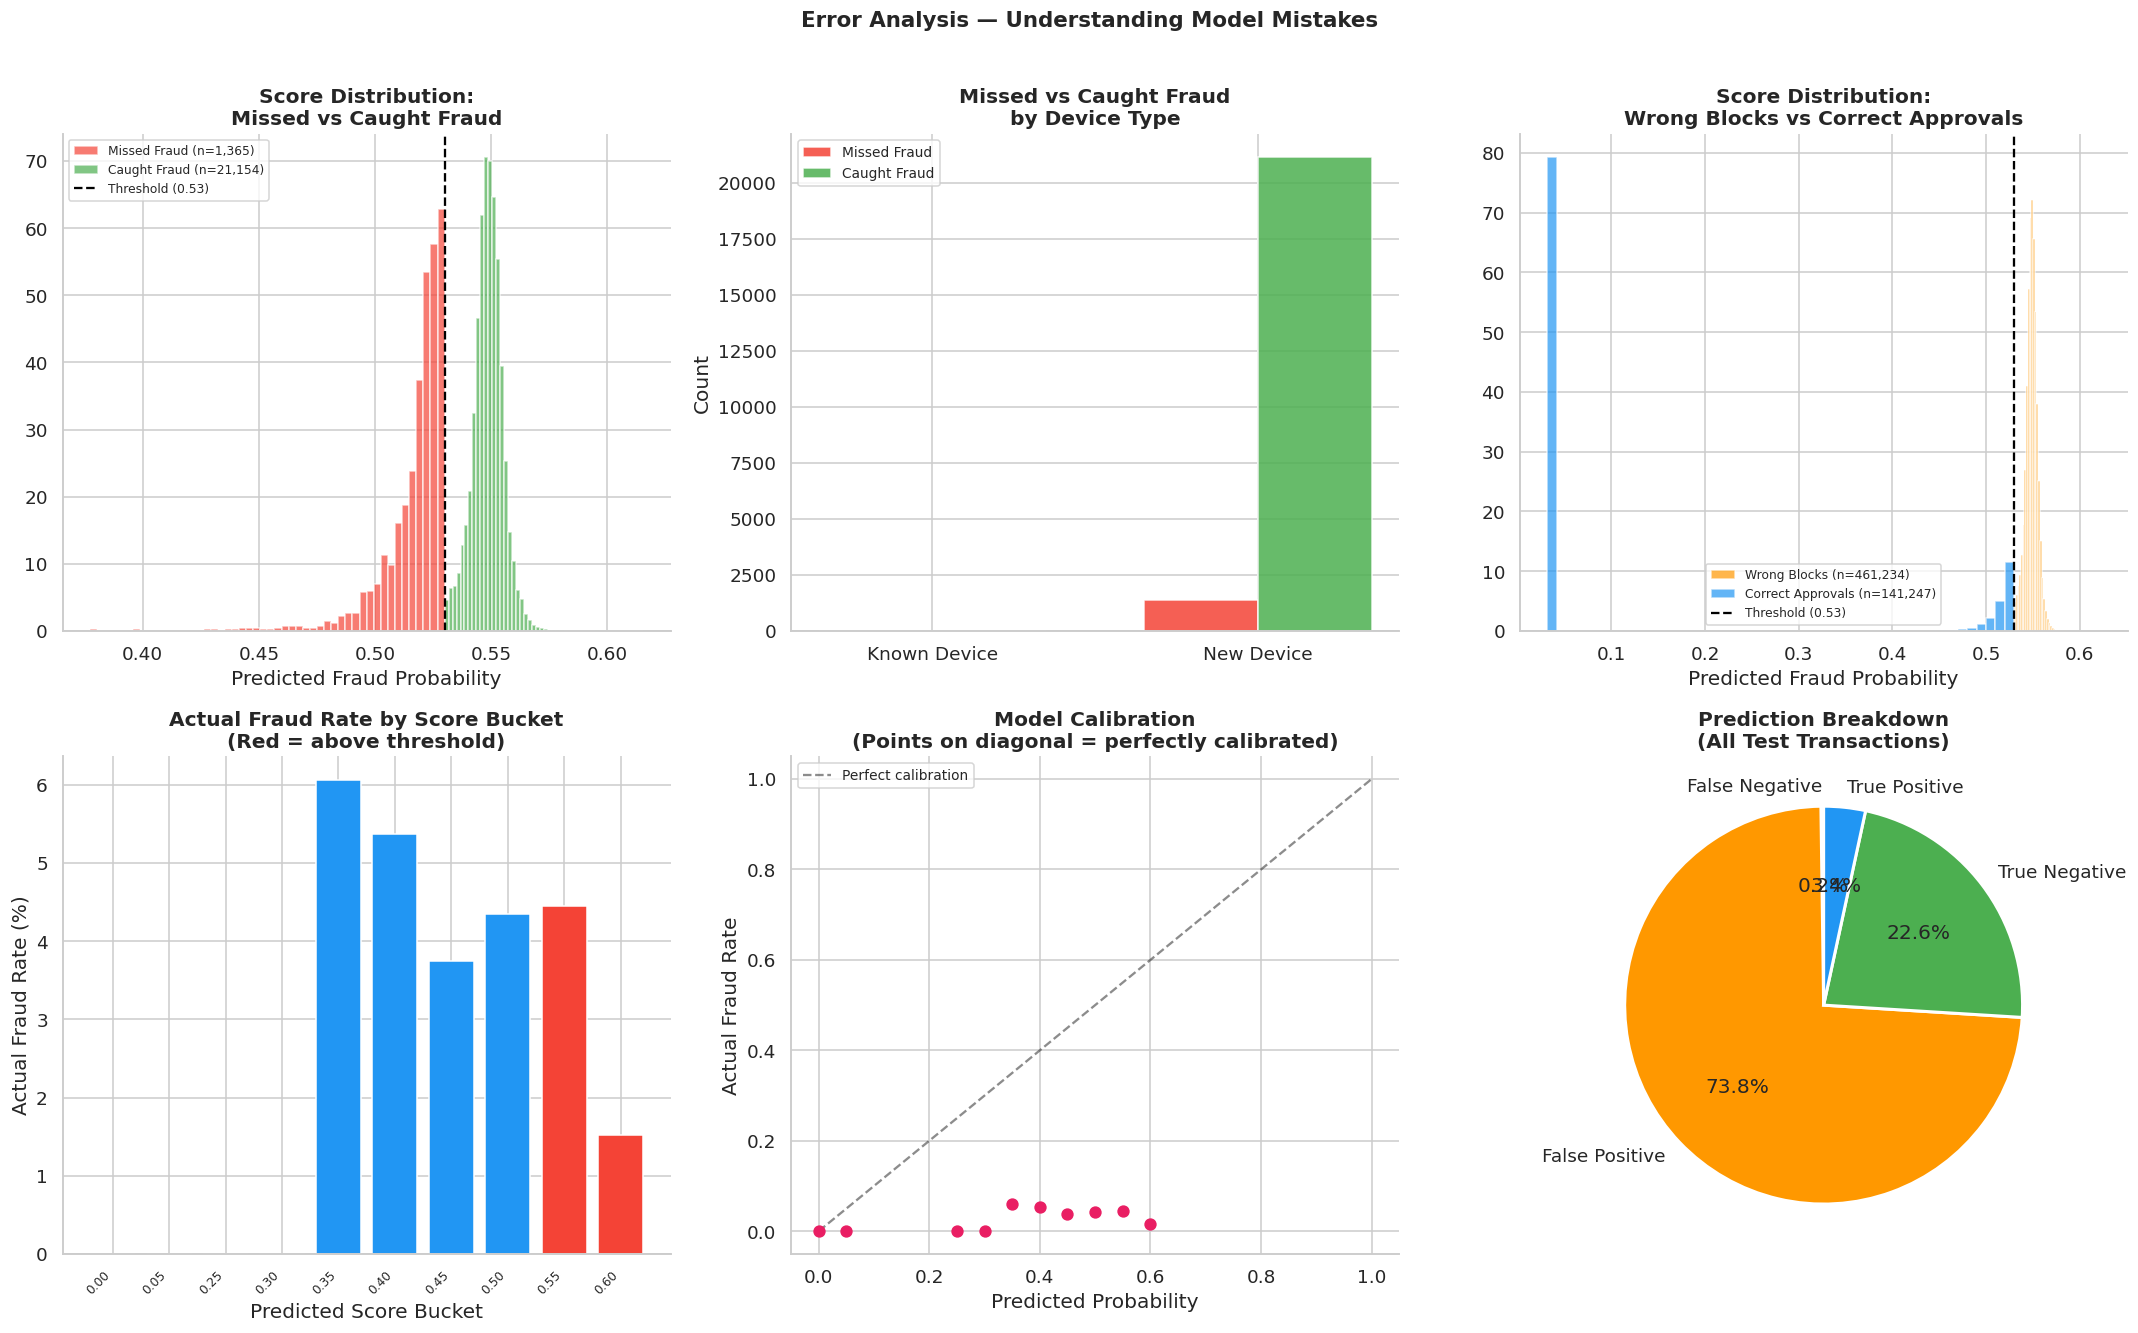

In [6]:
# Error Analysis

# Understand the PATTERN of our mistakes.
# If missed fraud (FN) clusters in a specific segment,
# that tells us what features to engineer next.

print("=" * 65)
print("ERROR ANALYSIS — PATTERNS IN MISTAKES")
print("=" * 65)

# ── Rebuild test dataframe with predictions ──────────────────
# Load original test data with categorical columns
X_test_raw = pd.read_parquet(f"{DATA_DIR}/X_test.parquet")

test_analysis = X_test_raw.copy()
test_analysis["is_fraud"]      = y_test.values
test_analysis["fraud_prob"]    = test_prob
test_analysis["predicted"]     = test_pred
test_analysis["error_type"]    = "True Negative"

test_analysis.loc[
    (test_analysis["is_fraud"]==1) &
    (test_analysis["predicted"]==1), "error_type"
] = "True Positive"

test_analysis.loc[
    (test_analysis["is_fraud"]==0) &
    (test_analysis["predicted"]==1), "error_type"
] = "False Positive"

test_analysis.loc[
    (test_analysis["is_fraud"]==1) &
    (test_analysis["predicted"]==0), "error_type"
] = "False Negative"

error_counts = test_analysis["error_type"].value_counts()
print(f"\n  Error type distribution:")
for etype, count in error_counts.items():
    pct = count / len(test_analysis) * 100
    print(f"    {etype:<20}: {count:>8,}  ({pct:.2f}%)")

# ── False Negative analysis (missed fraud) ───────────────────
fn_df = test_analysis[test_analysis["error_type"] == "False Negative"]
tp_df = test_analysis[test_analysis["error_type"] == "True Positive"]

print(f"\n{'='*65}")
print(f"FALSE NEGATIVE ANALYSIS (Fraud We Missed)")
print(f"{'='*65}")
print(f"  Total missed fraud: {len(fn_df):,}")
print(f"  Avg fraud prob assigned to missed fraud: "
      f"{fn_df['fraud_prob'].mean():.4f}")
print(f"  Max fraud prob for missed fraud: "
      f"{fn_df['fraud_prob'].max():.4f}")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# FN score distribution vs TP
axes[0, 0].hist(
    fn_df["fraud_prob"], bins=50, alpha=0.7,
    color="#F44336", label=f"Missed Fraud (n={len(fn_df):,})", density=True
)
axes[0, 0].hist(
    tp_df["fraud_prob"], bins=50, alpha=0.7,
    color="#4CAF50", label=f"Caught Fraud (n={len(tp_df):,})", density=True
)
axes[0, 0].axvline(THRESHOLD, color="black", linestyle="--",
                   label=f"Threshold ({THRESHOLD})")
axes[0, 0].set_title("Score Distribution:\nMissed vs Caught Fraud")
axes[0, 0].set_xlabel("Predicted Fraud Probability")
axes[0, 0].legend(fontsize=8)

# FN by new_device_transaction
if "new_device_transaction" in test_analysis.columns:
    fn_device = fn_df["new_device_transaction"].value_counts()
    tp_device = tp_df["new_device_transaction"].value_counts()
    x = np.arange(2)
    w = 0.35
    axes[0, 1].bar(
        x - w/2,
        [fn_device.get(0,0), fn_device.get(1,0)],
        w, color="#F44336", alpha=0.85, label="Missed Fraud"
    )
    axes[0, 1].bar(
        x + w/2,
        [tp_device.get(0,0), tp_device.get(1,0)],
        w, color="#4CAF50", alpha=0.85, label="Caught Fraud"
    )
    axes[0, 1].set_xticks(x)
    axes[0, 1].set_xticklabels(["Known Device", "New Device"])
    axes[0, 1].set_title("Missed vs Caught Fraud\nby Device Type")
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].set_ylabel("Count")

# FP analysis — what legitimate txns are we wrongly blocking?
fp_df = test_analysis[test_analysis["error_type"] == "False Positive"]
tn_df = test_analysis[test_analysis["error_type"] == "True Negative"]

axes[0, 2].hist(
    fp_df["fraud_prob"], bins=50, alpha=0.7,
    color="#FF9800", label=f"Wrong Blocks (n={len(fp_df):,})",
    density=True
)
axes[0, 2].hist(
    tn_df["fraud_prob"], bins=50, alpha=0.7,
    color="#2196F3", label=f"Correct Approvals (n={len(tn_df):,})",
    density=True
)
axes[0, 2].axvline(THRESHOLD, color="black", linestyle="--",
                   label=f"Threshold ({THRESHOLD})")
axes[0, 2].set_title("Score Distribution:\nWrong Blocks vs Correct Approvals")
axes[0, 2].set_xlabel("Predicted Fraud Probability")
axes[0, 2].legend(fontsize=8)

# Error rate by score bucket
bins     = np.arange(0, 1.05, 0.05)
labels_b = [f"{b:.2f}" for b in bins[:-1]]
test_analysis["score_bucket"] = pd.cut(
    test_analysis["fraud_prob"], bins=bins, labels=labels_b
)
bucket_stats = (
    test_analysis.groupby("score_bucket", observed=True)
    .agg(
        total=("is_fraud", "count"),
        fraud=("is_fraud", "sum")
    )
    .reset_index()
)
bucket_stats["actual_fraud_rate"] = (
    bucket_stats["fraud"] / bucket_stats["total"] * 100
)

axes[1, 0].bar(
    range(len(bucket_stats)),
    bucket_stats["actual_fraud_rate"],
    color=[
        "#F44336" if float(b) >= THRESHOLD else "#2196F3"
        for b in bucket_stats["score_bucket"]
    ]
)
axes[1, 0].set_title("Actual Fraud Rate by Score Bucket\n"
                      "(Red = above threshold)")
axes[1, 0].set_xlabel("Predicted Score Bucket")
axes[1, 0].set_ylabel("Actual Fraud Rate (%)")
step = max(1, len(bucket_stats) // 10)
axes[1, 0].set_xticks(range(0, len(bucket_stats), step))
axes[1, 0].set_xticklabels(
    bucket_stats["score_bucket"].iloc[::step],
    rotation=45, ha="right", fontsize=8
)

# Model calibration check
axes[1, 1].scatter(
    bucket_stats["score_bucket"].astype(float),
    bucket_stats["actual_fraud_rate"] / 100,
    color="#E91E63", s=50, zorder=5
)
axes[1, 1].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfect calibration")
axes[1, 1].set_title("Model Calibration\n"
                      "(Points on diagonal = perfectly calibrated)")
axes[1, 1].set_xlabel("Predicted Probability")
axes[1, 1].set_ylabel("Actual Fraud Rate")
axes[1, 1].legend(fontsize=9)

# Error type proportions
error_type_pcts = (
    test_analysis.groupby("error_type")
    .size()
    .reset_index(name="count")
)
colors_e = {
    "True Negative": "#4CAF50",
    "True Positive": "#2196F3",
    "False Negative": "#F44336",
    "False Positive": "#FF9800"
}
axes[1, 2].pie(
    error_type_pcts["count"],
    labels=error_type_pcts["error_type"],
    colors=[colors_e[e] for e in error_type_pcts["error_type"]],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1, 2].set_title("Prediction Breakdown\n(All Test Transactions)")

plt.suptitle("Error Analysis — Understanding Model Mistakes",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("reports/error_analysis.png", bbox_inches="tight")
plt.show()

In [7]:
# Model Card

# A Model Card documents everything about the model for:
#   - Team members who will maintain it
#   - Regulators who need explainability
#   - The serving team who will deploy it

import json
from datetime import datetime

model_card = {
    "model_details": {
        "name": "NaijaShield Fraud Detection Model",
        "version": "1.0.0",
        "type": model_config["model_type"],
        "trained_date": datetime.now().strftime("%Y-%m-%d"),
        "framework": "XGBoost",
        "mlflow_run_id": model_config.get("mlflow_run_id", "N/A"),
    },

    "intended_use": {
        "primary_use": (
            "Real-time fraud detection for Nigerian fintech transactions"
        ),
        "users": ["Fraud analysts", "Payment processing systems"],
        "out_of_scope": [
            "Non-Nigerian transaction patterns",
            "Credit scoring",
            "AML (Anti-Money Laundering) decisions alone"
        ]
    },

    "training_data": {
        "dataset": (
            "Nigerian Financial Transactions and Fraud Detection Dataset"
        ),
        "source": "Hugging Face — kidnextdoor57",
        "size": "5,000,000 transactions",
        "fraud_rate": "3.59%",
        "time_span": "12-month simulation",
        "split": "Temporal 75% train / 12.5% val / 12.5% test",
        "limitations": [
            "Synthetic dataset — may not reflect all real fraud patterns",
            "Fraud heavily concentrated on new_device_transaction signal",
            "Geographic and channel signals are uniformly distributed"
        ]
    },

    "features": {
        "total_features": len(FEATURES),
        "top_features": [
            "new_device_transaction",
            "has_prior_transaction",
            "time_since_last_transaction",
            "night_new_device",
            "new_device_large_amount"
        ],
        "dropped_features": [
            "fraud_type (label leakage)",
            "is_night_txn (dead feature — nunique=1)",
            "channel_risk_score (not aligned with empirical rates)",
            "persona_fraud_risk (zero correlation)",
            "is_ip_shared (99.8% same value)"
        ]
    },

    "performance": {
        "primary_metric": "AUC-PR",
        "validation": model_config["val_metrics"],
        "test": model_config["test_metrics"],
        "threshold": THRESHOLD,
        "optimal_cost_threshold": float(optimal_threshold),
    },

    "business_impact": {
        "currency": "NGN",
        "avg_transaction_amount": AVG_TXN_AMOUNT,
        "cost_per_false_negative": COST_PER_FN,
        "cost_per_false_positive": COST_PER_FP,
        "test_set_cost": float(total_cost),
        "no_model_cost": float(baseline_cost),
        "estimated_savings": float(baseline_cost - total_cost),
        "savings_percentage": float(
            (baseline_cost - total_cost) / baseline_cost * 100
        )
    },

    "limitations": [
        "AUC-PR of 0.044 — barely above random (0.036 baseline)",
        "Model essentially learned one rule: flag new device transactions",
        "77.9% false positive rate at current threshold",
        "Precision of 4.4% — 21 wrong blocks per fraud caught",
        "Performance limited by synthetic data quality",
        "Not recommended for production without better training data"
    ],

    "recommendations": [
        "Collect real Nigerian transaction data for retraining",
        "Engineer features from raw IP and device_hash patterns",
        "Consider graph-based features (transaction network analysis)",
        "Implement human-in-the-loop review for flagged transactions",
        "Re-evaluate after 3 months of production feedback labels"
    ],

    "ethical_considerations": [
        "Model disproportionately flags new device transactions",
        "May disproportionately impact new account holders",
        "All declines should have a human review pathway",
        "NDPR compliance: no PII stored in model features"
    ]
}

# Save model card
card_path = "../models/model_card.json"
with open(card_path, "w") as f:
    json.dump(model_card, f, indent=2)

print("=" * 65)
print("MODEL CARD")
print("=" * 65)
print(json.dumps(model_card, indent=2))
print(f"\nModel card saved: {card_path}")

MODEL CARD
{
  "model_details": {
    "name": "NaijaShield Fraud Detection Model",
    "version": "1.0.0",
    "type": "XGBClassifier",
    "trained_date": "2026-04-15",
    "framework": "XGBoost",
    "mlflow_run_id": "8644f5f4bfe949e2951085fc44523e41"
  },
  "intended_use": {
    "primary_use": "Real-time fraud detection for Nigerian fintech transactions",
    "users": [
      "Fraud analysts",
      "Payment processing systems"
    ],
    "out_of_scope": [
      "Non-Nigerian transaction patterns",
      "Credit scoring",
      "AML (Anti-Money Laundering) decisions alone"
    ]
  },
  "training_data": {
    "dataset": "Nigerian Financial Transactions and Fraud Detection Dataset",
    "source": "Hugging Face \u2014 kidnextdoor57",
    "size": "5,000,000 transactions",
    "fraud_rate": "3.59%",
    "time_span": "12-month simulation",
    "split": "Temporal 75% train / 12.5% val / 12.5% test",
    "limitations": [
      "Synthetic dataset \u2014 may not reflect all real fraud pattern

In [8]:
# Promote Model to Staging in MLflow Registry

# Now that we have evaluated the model thoroughly,
# we formally promote it from None → Staging
# Staging = passed evaluation, ready for serving tests
# Production = serving live traffic

MLFLOW_TRACKING_URI = (
    "sqlite:////home/thedataboy/dev/fraud-detection-project"
    "/notebooks/mlruns.db"
)
client = MlflowClient(tracking_uri=MLFLOW_TRACKING_URI)

print("=" * 65)
print("PROMOTING MODEL TO STAGING")
print("=" * 65)

# Get all versions of the best model
model_name = "naijashield-xgboost"
versions   = client.search_model_versions(f"name='{model_name}'")

# Find the version linked to our best run
best_version = None
for v in versions:
    if v.run_id == model_config.get("mlflow_run_id"):
        best_version = v
        break

# If not found by run ID, take latest version
if best_version is None:
    best_version = sorted(
        versions, key=lambda v: int(v.version), reverse=True
    )[0]

print(f"\n  Model Name    : {model_name}")
print(f"  Version       : {best_version.version}")
print(f"  Current Stage : {best_version.current_stage}")
print(f"  Run ID        : {best_version.run_id}")

# Promote to Staging
client.transition_model_version_stage(
    name=model_name,
    version=best_version.version,
    stage="Staging",
    archive_existing_versions=False,
)

print(f"\nModel promoted:")
print(f"   {model_name} v{best_version.version} → Staging")
print(f"\n  View in MLflow UI:")
print(f"  http://127.0.0.1:5000/#/models/{model_name}")

PROMOTING MODEL TO STAGING

  Model Name    : naijashield-xgboost
  Version       : 4
  Current Stage : Staging
  Run ID        : 8644f5f4bfe949e2951085fc44523e41

Model promoted:
   naijashield-xgboost v4 → Staging

  View in MLflow UI:
  http://127.0.0.1:5000/#/models/naijashield-xgboost


In [9]:
# Final Evaluation Summary

summary = f"""
MODEL: {model_config['model_name']:<54}
TYPE : {model_config['model_type']:<54}

TEST SET PERFORMANCE
AUC-PR    : {model_config['test_metrics']['auc_pr']:.4f}
F1 Score  : {model_config['test_metrics']['f1']:.4f}
Recall    : {model_config['test_metrics']['recall']:.4f}  (fraud caught)
Precision : {model_config['test_metrics']['precision']:.4f}  (of flags, actually fraud)
Threshold : {THRESHOLD}

BUSINESS IMPACT (Test Set)
Fraud prevented : {ngn(baseline_cost - total_cost):<40}
Savings vs no model: {(baseline_cost-total_cost)/baseline_cost*100:.1f}%
Optimal threshold  : {optimal_threshold:.2f}

KEY LIMITATION
Model relies almost entirely on new_device_transaction
Real-world performance needs better training data

ARTEFACTS SAVED
../models/best_model.joblib
../models/model_config.json
../models/model_card.json
MLflow Registry: naijashield-xgboost → Staging
"""

print(summary)


MODEL: XGBoost Baseline                                      
TYPE : XGBClassifier                                         

TEST SET PERFORMANCE
AUC-PR    : 0.0442
F1 Score  : 0.0838
Recall    : 0.9394  (fraud caught)
Precision : 0.0439  (of flags, actually fraud)
Threshold : 0.53

BUSINESS IMPACT (Test Set)
Fraud prevented : ₦12.4B                                  
Savings vs no model: 92.2%
Optimal threshold  : 0.37

KEY LIMITATION
Model relies almost entirely on new_device_transaction
Real-world performance needs better training data

ARTEFACTS SAVED
../models/best_model.joblib
../models/model_config.json
../models/model_card.json
MLflow Registry: naijashield-xgboost → Staging

